In [1]:
%matplotlib inline
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FEATURES_PATH = PROJECT_ROOT / "dataset" / "features_3.0_sec.json"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)
print(FEATURES_PATH)

C:\Users\Muham\Desktop\Data (1)\music-genre-classification
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\features_3.0_sec.json


In [2]:
with FEATURES_PATH.open("r", encoding="utf-8") as fp:
    data = json.load(fp)

X = np.array(data["mfcc"], dtype=np.float32)
y = np.array(data["genre_num"], dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (5594, 132, 13) y_train: (5594,)
X_val: (1399, 132, 13) y_val: (1399,)
X_test: (2997, 132, 13) y_test: (2997,)


In [3]:
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, Dense, Dropout, LSTM, MaxPooling2D, Reshape, SimpleRNN
from tensorflow.keras.optimizers import Adam

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]
input_shape = X_train.shape[1:]
print(input_shape)

(132, 13)


In [4]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["accuracy"], label="training accuracy")
    axes[0].plot(history.history["val_accuracy"], label="validation accuracy")
    axes[0].set_title(title + " - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(history.history["loss"], label="training loss")
    axes[1].plot(history.history["val_loss"], label="validation loss")
    axes[1].set_title(title + " - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(model, X_current, y_current, title):
    y_pred = np.argmax(model.predict(X_current, verbose=0), axis=1)
    cm = confusion_matrix(y_current, y_pred)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRES)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_current, y_pred, target_names=GENRES, zero_division=0))
    return y_pred

In [5]:
def build_simple_rnn(input_shape):
    model = Sequential(name="simple_rnn_low")
    model.add(SimpleRNN(128, activation="tanh", input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(len(GENRES), activation="softmax"))
    return model


def build_cnn_lstm(input_shape):
    model = Sequential(name="cnn_lstm_high")
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(input_shape[0], input_shape[1], 1)))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))
    model.add(Reshape((33, 3 * 64)))
    model.add(LSTM(128, activation="tanh"))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(len(GENRES), activation="softmax"))
    return model

Dusuk basari modeli - SimpleRNN


C:\Users\Muham\Desktop\Data (1)\music-genre-classification\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "simple_rnn_low"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,082 (105.79 KB)

...

Epoch 33/120


88/88 - 1s - 16ms/step - accuracy: 0.3064 - loss: 1.9193 - val_accuracy: 0.3410 - val_loss: 1.8598 - learning_rate: 1.0000e-04


Epoch 34/120


88/88 - 1s - 16ms/step - accuracy: 0.3175 - loss: 1.9093 - val_accuracy: 0.3381 - val_loss: 1.8562 - learning_rate: 1.0000e-04


Training accuracy: 0.3441
Validation accuracy: 0.3474
Test accuracy: 0.3287
Loss: 1.8763
Validation loss: 1.9123
Test loss: 1.9050


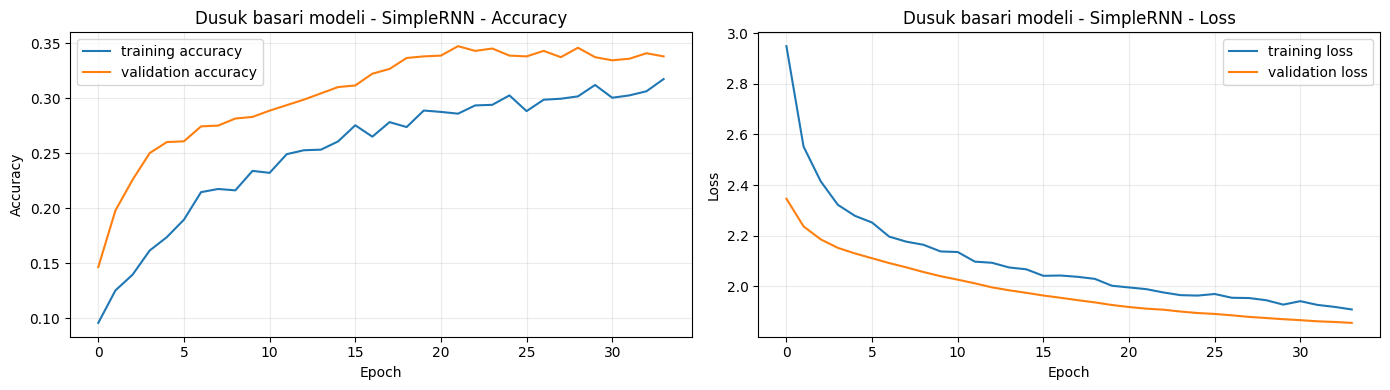

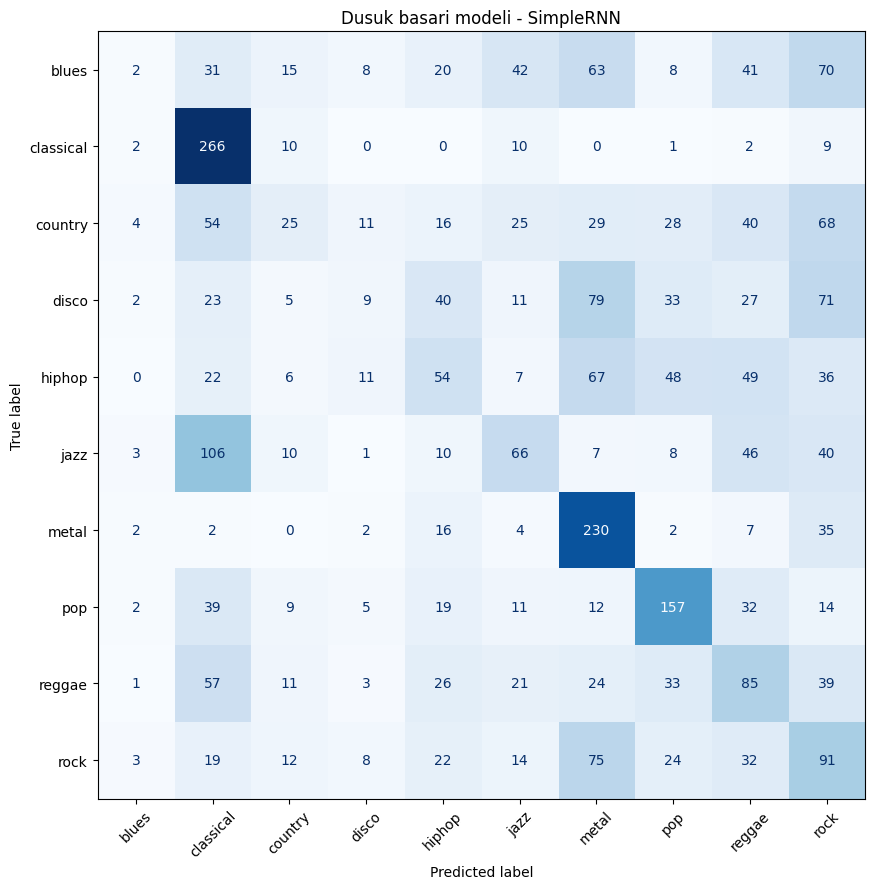

              precision    recall  f1-score   support

       blues       0.10      0.01      0.01       300
   classical       0.43      0.89      0.58       300
     country       0.24      0.08      0.12       300
       disco       0.16      0.03      0.05       300
      hiphop       0.24      0.18      0.21       300
        jazz       0.31      0.22      0.26       297
       metal       0.39      0.77      0.52       300
         pop       0.46      0.52      0.49       300
      reggae       0.24      0.28      0.26       300
        rock       0.19      0.30      0.24       300

    accuracy                           0.33      2997
   macro avg       0.28      0.33      0.27      2997
weighted avg       0.28      0.33      0.27      2997

Yuksek basari adayi - CNN + LSTM


C:\Users\Muham\Desktop\Data (1)\music-genre-classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_lstm_high"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 132, 13, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 66, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 66, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 66, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 33, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 33, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 33, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 192,074 (750.29 KB)

...

Epoch 85/120


88/88 - 3s - 34ms/step - accuracy: 0.8248 - loss: 0.5224 - val_accuracy: 0.7791 - val_loss: 0.7290 - learning_rate: 7.8125e-06


Epoch 86/120


88/88 - 3s - 36ms/step - accuracy: 0.8289 - loss: 0.5010 - val_accuracy: 0.7820 - val_loss: 0.7410 - learning_rate: 7.8125e-06


Training accuracy: 0.8402
Validation accuracy: 0.7863
Test accuracy: 0.7684
Loss: 0.4761
Validation loss: 0.7130
Test loss: 0.7515


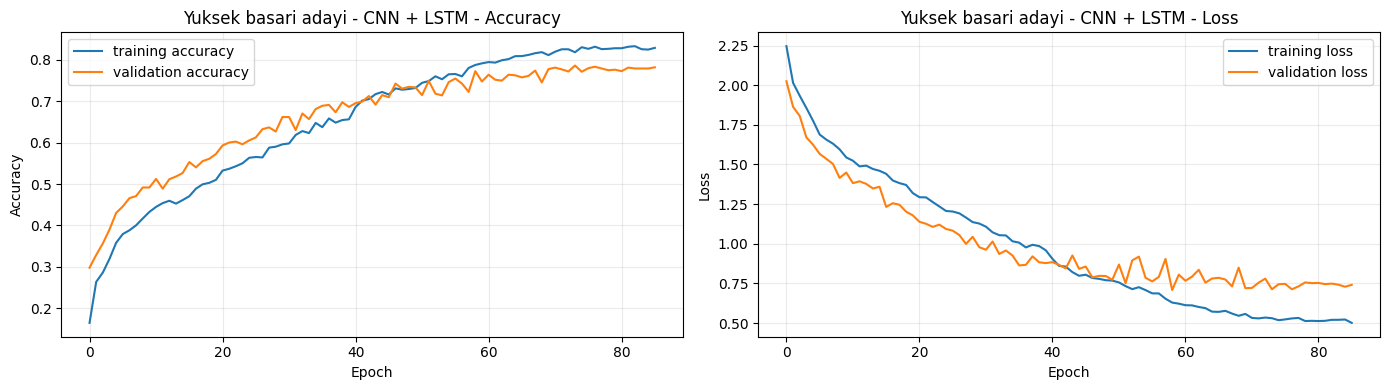

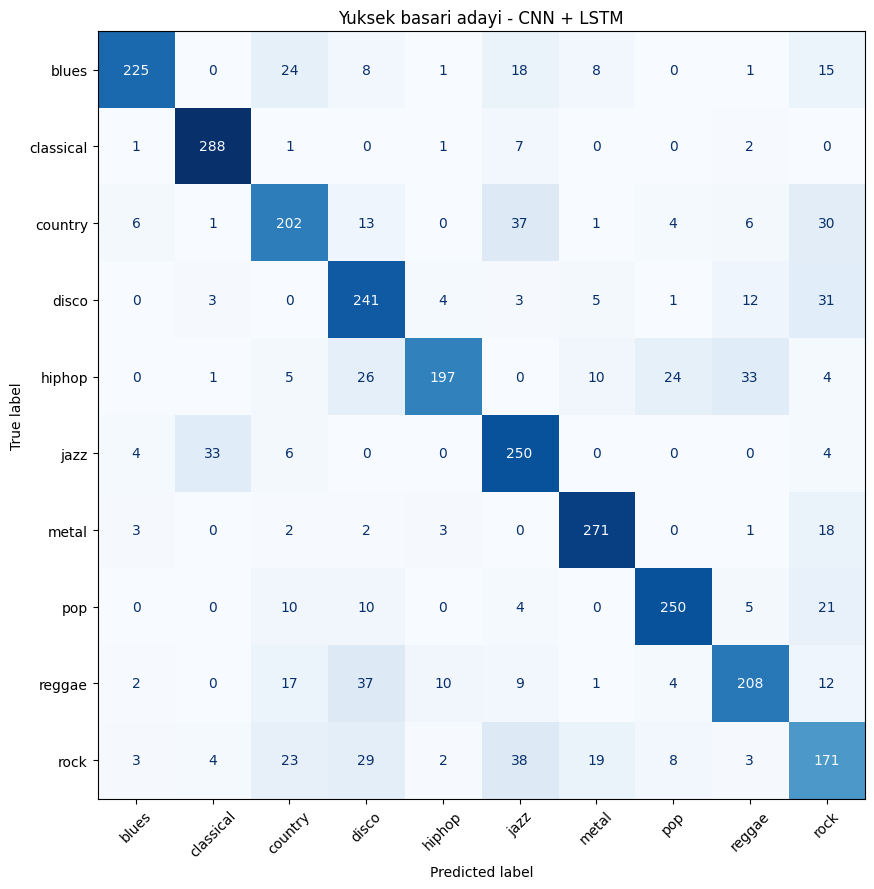

              precision    recall  f1-score   support

       blues       0.92      0.75      0.83       300
   classical       0.87      0.96      0.91       300
     country       0.70      0.67      0.68       300
       disco       0.66      0.80      0.72       300
      hiphop       0.90      0.66      0.76       300
        jazz       0.68      0.84      0.75       297
       metal       0.86      0.90      0.88       300
         pop       0.86      0.83      0.85       300
      reggae       0.77      0.69      0.73       300
        rock       0.56      0.57      0.56       300

    accuracy                           0.77      2997
   macro avg       0.78      0.77      0.77      2997
weighted avg       0.78      0.77      0.77      2997



In [6]:
EPOCHS = 120
BATCH_SIZE = 64
TRIALS = [
    {
        "label": "Dusuk basari modeli - SimpleRNN",
        "builder": build_simple_rnn,
        "train_X": X_train,
        "val_X": X_val,
        "test_X": X_test,
        "learning_rate": 0.0001,
    },
    {
        "label": "Yuksek basari adayi - CNN + LSTM",
        "builder": build_cnn_lstm,
        "train_X": X_train_cnn,
        "val_X": X_val_cnn,
        "test_X": X_test_cnn,
        "learning_rate": 0.001,
    },
]

results = []
trained_models = {}
histories = {}

for trial in TRIALS:
    model_name = trial["label"]
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    model = trial["builder"](input_shape)
    model.compile(optimizer=Adam(learning_rate=trial["learning_rate"]), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    display(model.summary())
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(MODELS_DIR / f"{model.name}_checkpoint.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history = model.fit(trial["train_X"], y_train, validation_data=(trial["val_X"], y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=2)
    train_loss, train_accuracy = model.evaluate(trial["train_X"], y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(trial["val_X"], y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(trial["test_X"], y_test, verbose=0)
    y_pred = np.argmax(model.predict(trial["test_X"], verbose=0), axis=1)
    results.append({
        "model": model_name,
        "training_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "loss": train_loss,
        "validation_loss": val_loss,
        "test_loss": test_loss,
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "epochs_run": len(history.history["loss"]),
    })
    trained_models[model_name] = model
    histories[model_name] = history
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Test loss: {test_loss:.4f}")
    plot_history(history, model_name)
    show_confusion_matrix(model, trial["test_X"], y_test, model_name)

In [7]:
comparison_df = pd.DataFrame(results).sort_values("validation_accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)
comparison_df.to_csv(MODELS_DIR / "rnn_lstm_model_comparison.csv", index=False, encoding="utf-8-sig")

best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_model.save(MODELS_DIR / "best_rnn_lstm_model.keras")
best_model.save(MODELS_DIR / "best_rnn_lstm_model.h5")
print("En iyi RNN/LSTM model:", best_model_name)
print("Validation accuracy:", comparison_df.iloc[0]["validation_accuracy"])
print(MODELS_DIR / "best_rnn_lstm_model.keras")
print(MODELS_DIR / "best_rnn_lstm_model.h5")

,model,training_accuracy,validation_accuracy,test_accuracy,loss,validation_loss,test_loss,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,epochs_run
0,Yuksek basari adayi - CNN + LSTM,0.840186,0.786276,0.768435,0.476131,0.712978,0.751538,0.778239,0.778334,0.768508,0.768435,0.768495,0.768510,86
1,Dusuk basari modeli - SimpleRNN,0.344119,0.347391,0.328662,1.876304,1.912330,1.904993,0.275720,0.275683,0.328556,0.328662,0.273296,0.273309,34


En iyi RNN/LSTM model: Yuksek basari adayi - CNN + LSTM
Validation accuracy: 0.7862759232521057
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_rnn_lstm_model.keras
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_rnn_lstm_model.h5
